In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("..\Data\credit_card_fraud_10k.csv")

df_copy=df.copy()

In [3]:
df

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


drop cardholderage,transaction _id and merchant_category(they dont have much pattern and dont help model to learn from their pattern)

In [4]:
df.drop(columns=['transaction_id','merchant_category','cardholder_age'],inplace=True)
df_copy.drop(columns=['transaction_id','merchant_category','cardholder_age'],inplace=True)


Plot Heatmap 

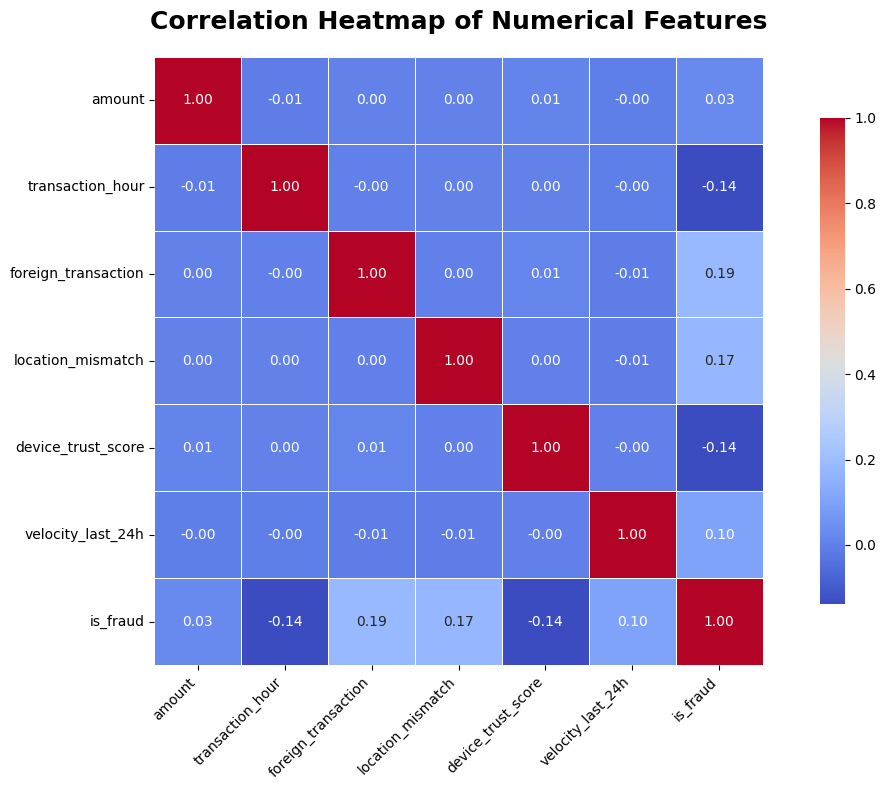

In [5]:



corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 10}
    )

plt.title(
        "Correlation Heatmap of Numerical Features",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.show()

In [ ]:
=[col for col in df.columns inum_featuresf df[col].dtypes!='O']

In [7]:
num_features

['amount',
 'transaction_hour',
 'foreign_transaction',
 'location_mismatch',
 'device_trust_score',
 'velocity_last_24h',
 'is_fraud']

Multicollinearity check using VIF

In [8]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(df, numerical_features):
    """
    Calculate Variance Inflation Factor (VIF) for numerical features.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe.
    numerical_features : list
        List of numerical column names.

    Returns:
    --------
    pandas.DataFrame
        DataFrame containing VIF values and interpretation.
    """

    X = df[numerical_features].dropna().copy()

    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    def interpret(vif):
        if vif < 5:
            return "Low"
        elif vif < 10:
            return "Moderate"
        else:
            return "High"

    vif_data["Multicollinearity"] = vif_data["VIF"].apply(interpret)

    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

In [9]:
check_vif(df=df,numerical_features=num_features)

,Feature,VIF,Multicollinearity
0,device_trust_score,4.322400,Low
1,transaction_hour,3.134242,Low
2,velocity_last_24h,2.649533,Low
3,amount,1.885531,Low
4,foreign_transaction,1.149977,Low
5,is_fraud,1.129065,Low
6,location_mismatch,1.128414,Low


Report:

Dropped the Unnecessary Columns

No Multicollieaniry in Our data 

In [10]:
df

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,is_fraud
0,84.47,22,0,0,66,3,0
1,541.82,3,1,0,87,1,0
2,237.01,17,0,0,49,1,0
3,164.33,4,0,1,72,3,0
4,30.53,15,0,0,79,0,0
...,...,...,...,...,...,...,...
9995,350.91,22,0,0,99,4,0
9996,410.04,5,0,0,70,3,0
9997,527.75,21,0,0,44,2,0
9998,91.20,2,0,0,38,0,0


We are going to make new feature,where we combine our rule and assign a score related to fraud and predict the fraud score using model


and assing that top approve,review and reject


It's also knowns as Hybrid Sytem

Incoming Transaction

        │

        ▼

Feature Engineering

        │

        ├──────────────┐

        ▼              ▼

 Rule Engine      ML Model (XGBoost or Random Forest)
        │
                      │

 Rule Score      Fraud Probability
        │              │
        └──────┬───────┘
               ▼
               
      Risk Scoring Engine

               │

               ▼
               
Approve / Review / Block


Check outlier first suing IQR Method 

In [11]:


def check_outliers(df, columns, plot=True):

    summary = []

    for col in columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

        summary.append({
            "Feature": col,
            "Outlier Count": outlier_count,
            "Outlier %": round(outlier_count / len(df) * 100, 2),
            "Lower Bound": round(lower, 2),
            "Upper Bound": round(upper, 2)
        })

        if plot:
            plt.figure(figsize=(8, 2.5))
            plt.boxplot(df[col].dropna(), vert=False)
            plt.title(f"Boxplot of {col}")
            plt.xlabel(col)
            plt.grid(alpha=0.3)
            plt.show()

    return pd.DataFrame(summary)

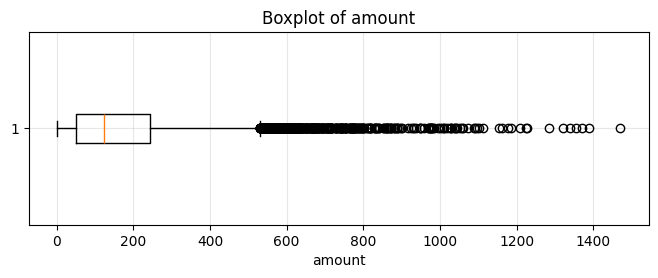

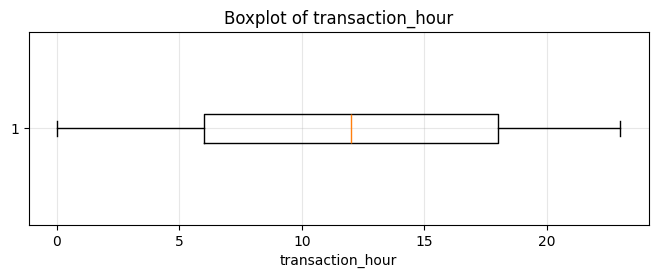

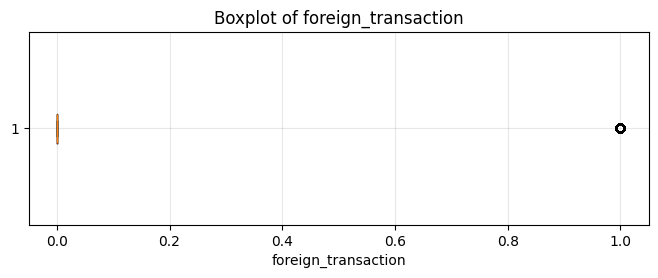

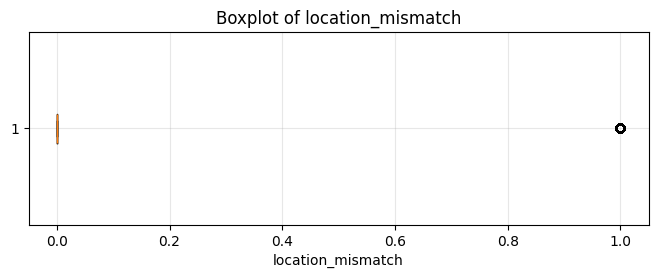

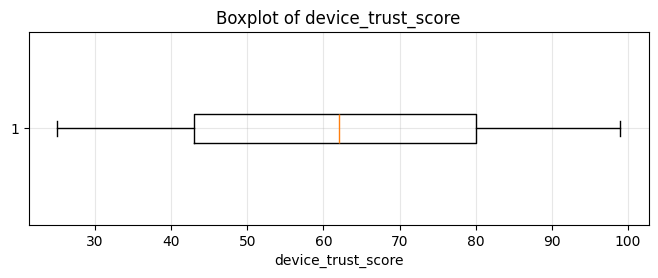

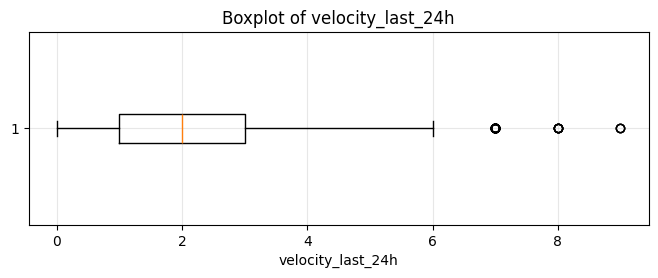

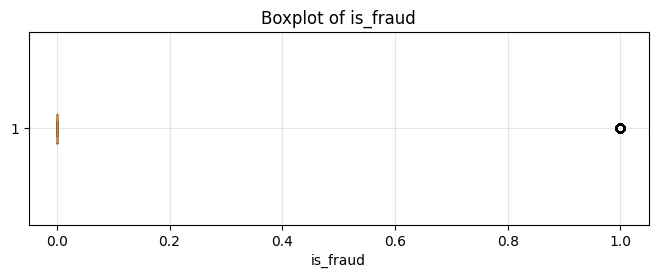

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,amount,501,5.01,-236.46,529.84
1,transaction_hour,0,0.00,-12.00,36.00
2,foreign_transaction,978,9.78,0.00,0.00
3,location_mismatch,857,8.57,0.00,0.00
4,device_trust_score,0,0.00,-12.50,135.50
5,velocity_last_24h,51,0.51,-2.00,6.00
6,is_fraud,151,1.51,0.00,0.00


In [12]:
check_outliers(df=df,columns=num_features)

In [13]:
# Here we dont need to remove outlier ,it might  be beneficial for model to leanr in fraud detection also model like random forest and xgboost dont have any eefetc on model

Define Rules,According to our Understanding

Amount->In EDA we Saw there is not any proof or something that we can say highere amount lead to fraud,so for this constraints we 

nothing assign it

transaction_hour-> Similary we saw in EDA ,transaction between (12:00 am to 3:00 am ) leads to higher fraud rate 

assign values  to it
 

foreign_transaction-> In This ,we dot have any evidence in data so keep it minimal values according to our buissness goal


location_mismatch->This is also and high rated fraud constarint so assign value just like transaction_hour


device_trust_score-> we have seen lower device score leads to fraud so assign high value to it

 Velocity_last_24h-> In this also ,there is not strong pattern in it ,so keep it or not assign values to it







In [14]:
def rule(row):
  
    score = 0

    if row["transaction_hour"] in [0, 1, 2, 3]:
        score += 30

    if row["foreign_transaction"] == 1:
        score += 20

    if row["location_mismatch"] == 1:
        score += 25

    if row["device_trust_score"] < 60:
        score += 25
    return score

we are going to train two models ,one with using smote and other without smote 

In [15]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,ConfusionMatrixDisplay,f1_score,roc_auc_score,roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [16]:
X=df.drop(columns='is_fraud')
Y=df['is_fraud']


In [17]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2,stratify=Y)



In [18]:
st=StandardScaler()

X_train=st.fit_transform(X_train)
X_test=st.transform(X_test)


In [19]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    Y_train
)


In [20]:
y_train_smote.value_counts()

is_fraud
0    7879
1    7879
Name: count, dtype: int64

In [21]:
#fucntion to evaaluate model and trying diffrent algoroithms


#rather than accurcay ,more focus toward recall and precision

In [22]:



def evaluate_models(X_train, y_train, X_test, y_test):
    """
    Train and evaluate multiple classification models.

    Returns:
        pandas.DataFrame containing evaluation metrics.
    """

    models = {
        "Logistic Regression": LogisticRegression(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGBoost": XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    }

    results = []

    for name, model in models.items():

        # Train
        model.fit(X_train, y_train)

        # Prediction
        y_pred = model.predict(X_test)
        # Probability
        y_prob = model.predict_proba(X_test)[:, 1]
        


        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    

    return pd.DataFrame(results).sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9975,0.857143,1.0,0.923077,0.999797
1,XGBoost,0.9965,0.810811,1.0,0.895522,0.999966
2,Logistic Regression,0.9645,0.297030,1.0,0.458015,0.994585


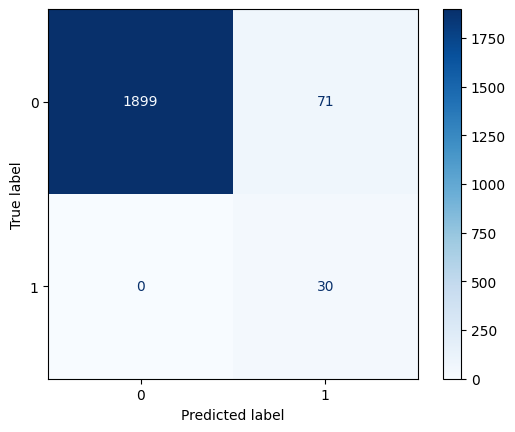

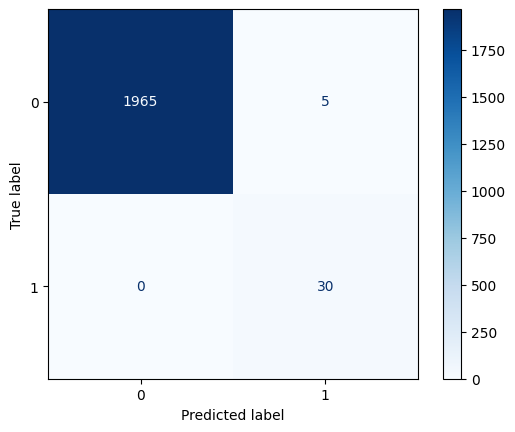

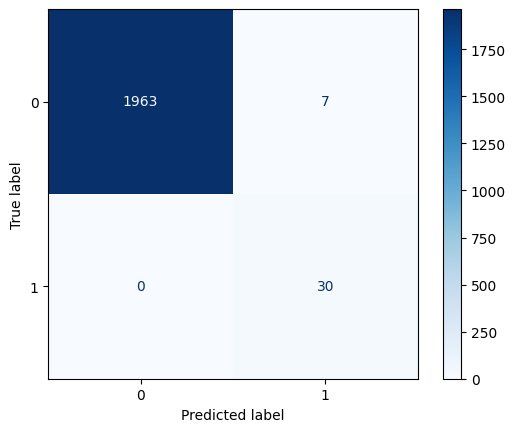

In [23]:
evaluate_models(X_train_smote, y_train_smote, X_test, Y_test)

In [24]:
#Lets go with random foreest and Tkae prob  and make rules and add this in your dataframe

In [25]:
randomforest=RandomForestClassifier()

randomforest.fit(X_train_smote,y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
y_pred=randomforest.predict(X_test)

In [27]:
y_pred_train=randomforest.predict(X_train_smote)

In [28]:
recall_score(y_pred_train,y_train_smote)

1.0

In [29]:
recall_score(y_pred,Y_test)



0.8529411764705882

In [30]:
precision_score(y_pred,Y_test)



0.9666666666666667

In [31]:
accuracy_score(y_pred,Y_test)

0.997

In [32]:
accuracy_score(y_pred_train,y_train_smote)

1.0

In [33]:
train_prob=randomforest.predict_proba(X_train)[:,-1] #prob of our model of prediction ,now from this we make our rule

Now, making rule of my model and add this in your data

In [34]:
#first here we usually weight learned by model itself in nn or in ml it is given by domain expertise , so based on this we take o.4 for our rules and 0.6 for our model

In [35]:
def calculate_fraud_score(model, df):

    # Calculate rule score for every row
    rule_score = df.apply(rule, axis=1)

    X=df.drop(columns='is_fraud',axis=1)

    # Predict probability
    model_prob = model.predict_proba(X)[:, 1]

    # Convert to 0-100
    ml_score = model_prob * 100
    print(ml_score)

    # Hybrid score
    final_score = 0.4 * rule_score + 0.6 * ml_score

    return final_score



In [36]:
df['fraud_score']=calculate_fraud_score(randomforest,df)

[ 9. 11. 11. ...  8.  8.  8.]


In [37]:
df[df['is_fraud']==1]['fraud_score'].value_counts()

fraud_score
29.8    15
37.2    13
26.8    11
34.8    10
22.2     9
32.8     8
39.2     7
37.4     7
36.8     6
36.6     6
24.8     6
35.4     5
37.8     5
39.8     4
34.2     4
40.4     4
44.8     4
32.2     4
46.6     3
24.2     3
38.6     3
28.6     2
34.6     2
47.2     2
27.4     2
27.2     1
36.0     1
22.4     1
25.0     1
44.2     1
27.8     1
Name: count, dtype: int64

Noe train the model on this Dataframe 

In [38]:
df

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,is_fraud,fraud_score
0,84.47,22,0,0,66,3,0,5.4
1,541.82,3,1,0,87,1,0,26.6
2,237.01,17,0,0,49,1,0,16.6
3,164.33,4,0,1,72,3,0,15.4
4,30.53,15,0,0,79,0,0,4.8
...,...,...,...,...,...,...,...,...
9995,350.91,22,0,0,99,4,0,4.8
9996,410.04,5,0,0,70,3,0,5.4
9997,527.75,21,0,0,44,2,0,14.8
9998,91.20,2,0,0,38,0,0,26.8


In [39]:
x=df.drop(columns=['is_fraud'],axis=1)
y=df['is_fraud']

In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [41]:
x_train.shape,x_test.shape

((8000, 7), (2000, 7))

In [42]:
#Train random forest model bt scale it first although tree models doesnt need it ,but let's do it

st=StandardScaler()

x_train=st.fit_transform(x_train)

x_test=st.transform(x_test)

In [43]:
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)


In [44]:
RandomForest=RandomForestClassifier()

RandomForest.fit(x_train_smote,y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
y_pred=RandomForest.predict(x_test)

In [46]:
accuracy_score(y_pred,y_test)

0.9975

In [47]:
#lets check train accuracy

y_pred_train=RandomForest.predict(x_train_smote)

accuracy_score(y_pred_train,y_train_smote)

#no overfitting here




1.0

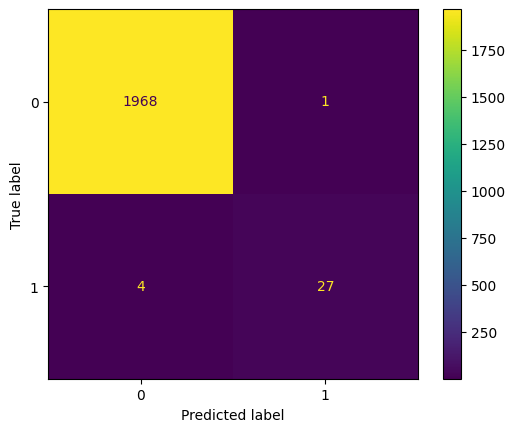

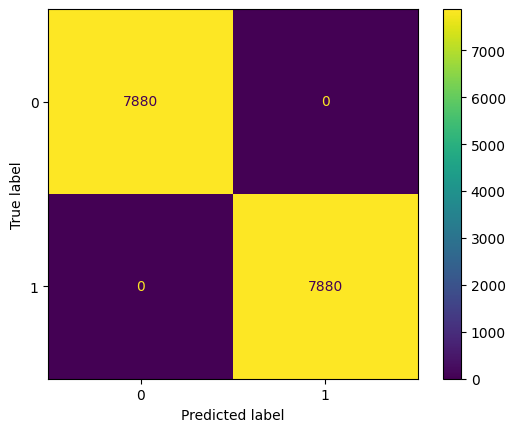

In [48]:
#lets plot confustion matrix and also recall and precision score
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)


ConfusionMatrixDisplay.from_predictions(y_pred_train,y_train_smote)

In [49]:
# Actually we'have got great model here

recall_score(y_pred,y_test)

0.9642857142857143

In [50]:
precision_score(y_pred,y_test)


0.8709677419354839

LET'S SEE WITHOUT SMOTE ,HOW MODEL WILL PERFORM

In [55]:
X=df_copy.drop(columns=['is_fraud'])
Y=df_copy['is_fraud']

X_train1,X_test1,Y_train1,Y_test1=train_test_split(X,Y,test_size=0.2,random_state=42)


RandomForestClassifierr=RandomForestClassifier()

RandomForestClassifierr.fit(X_train1,Y_train1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
df_copy['fraud_score']=calculate_fraud_score(RandomForestClassifierr,df_copy)

[0. 0. 0. ... 0. 0. 0.]


In [58]:
df_copy

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,is_fraud,fraud_score
0,84.47,22,0,0,66,3,0,0.0
1,541.82,3,1,0,87,1,0,20.0
2,237.01,17,0,0,49,1,0,10.0
3,164.33,4,0,1,72,3,0,10.0
4,30.53,15,0,0,79,0,0,0.0
...,...,...,...,...,...,...,...,...
9995,350.91,22,0,0,99,4,0,0.0
9996,410.04,5,0,0,70,3,0,0.0
9997,527.75,21,0,0,44,2,0,10.0
9998,91.20,2,0,0,38,0,0,22.0


In [60]:
X=df_copy.drop(columns=['is_fraud'])
Y=df_copy['is_fraud']

In [61]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [62]:
RandomForestClassifierr.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
y_pred=RandomForestClassifierr.predict(X_test)

In [65]:
accuracy_score(Y_test,y_pred)

0.998

In [67]:
Y_pred_train=RandomForestClassifierr.predict(X_train)

In [68]:
accuracy_score(Y_train,Y_pred_train)

1.0

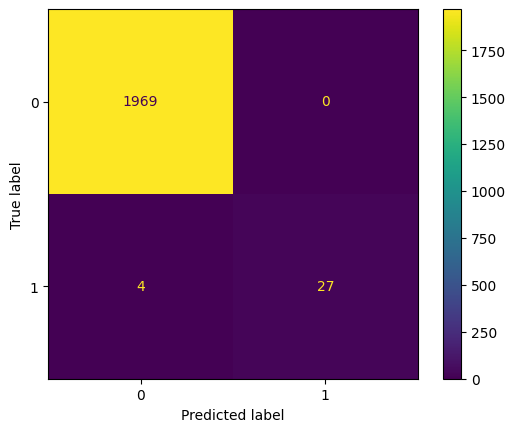

In [70]:
ConfusionMatrixDisplay.from_predictions(Y_test,y_pred)

#for testing data

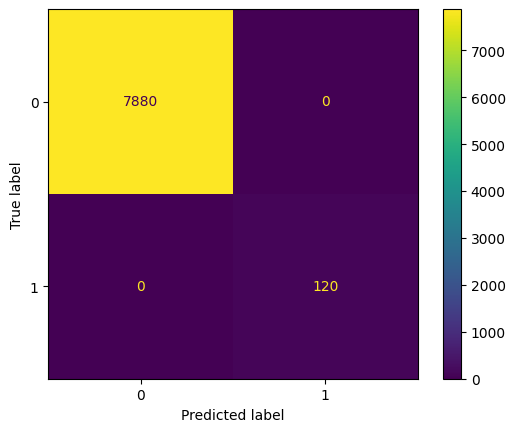

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_train,Y_pred_train)

# this is for traimig data

Final Conlcusion:


Both with Smote and without Smote they works well.

If we have more data then system will perform much better ,although results are satisfying

We have define rules and they are really good to have ,making model much understandable to learn patterns

All the features we have given is really important to predict outcome 


Now,making it to prodcution ready :

-> CI-CD

-> Fastapi endpoints

-> Aws cloud

-> DVC 

-> Mlflow

-> Docker

